In [82]:
from matplotlib import pyplot as plt  #pyplot 是 matplotlib 裡最常用來畫圖的模組。
import tensorflow as tf          # 機器學習／深度學習框架
from tensorflow import keras as K    # 高階神經網路 API（建立與訓練模型）
import numpy as np


In [61]:
mnist=K.datasets.mnist  #載入資料集

In [62]:
mnist  #查看是否載入成功

<module 'keras.datasets.mnist' from '/usr/local/lib/python3.12/dist-packages/keras/datasets/mnist/__init__.py'>

In [63]:
(X_train,y_train),(X_test,y_test)=mnist.load_data() #定義測試集跟資料集

| 小 batch | 大 batch |
| ------- | ------- |
| 更新多次    | 更新少次    |
| 有雜訊     | 穩定      |
| 可能泛化好   | 可能卡局部   |

為什麼常見 16 / 32 / 64？

GPU 友善

2 的次方

經驗值


---
Epoch 太少 / 太多會怎樣？
| 太少           | 太多          |
| ------------ | ----------- |
| 還沒學會         | overfitting |
| underfitting | 記住資料        |


真正訓練常見：

20

50

100+


In [64]:
FIG_DIM=(6,4)  # 指定 matplotlib 圖表的大小（寬, 高）
         # 單位是 英吋（inch）
LEARNING_RATE=1e-3 #學習率：模型「每一步走多大步」
BATCH_SIZE= 16  #一次拿幾筆資料來算梯度
EPOCHS=3

In [65]:
print(X_train.shape)  # 確認資料量與影像大小
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [66]:
X_train.dtype

dtype('uint8')

**如果沒轉換型態(整數轉浮點)可能：**

1️⃣ 神經網路需要浮點數

TensorFlow / Keras 預設使用 float32

uint8（0~255）不適合直接丟進模型

2️⃣ 正規化（Normalization）

把像素從 0~255 → 0~1

讓梯度下降比較穩定、收斂比較快

3️⃣ 控制資料型態（避免 float64）

In [67]:
(X_train.astype('float32')/255.0).shape
(X_train.astype('float32')/255.0)[0]  #抓出第一筆出來看

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [68]:
X_train=X_train.astype('float32')/255.0
X_test=X_test.astype('float32')/255.0

畫樣本，資料集



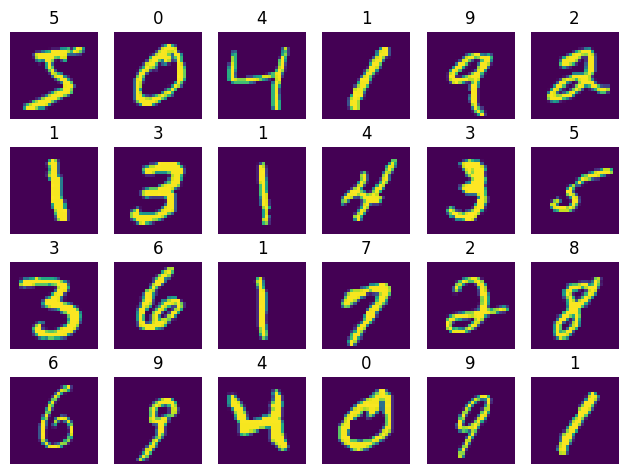

In [69]:
#老師的解答
#把 (x, y) 的「格子座標」轉成「一維 index」
for y in range(FIG_DIM[1]):    # 列（row）
  for x in range(FIG_DIM[0]):  # 欄（column）
    idx= x + y * FIG_DIM[0] # index = col + row * num_cols

    plt.subplot(FIG_DIM[1],FIG_DIM[0],idx+1) # plt.subplot(rows, cols, index)
    #idx+1: 因為matplotlib 的 subplot 編號從 1 開始，不是 0
    # FIG_DIM = (6, 4)
    # FIG_DIM[0] = 6 → 欄數（columns）
    # FIG_DIM[1] = 4 → 列數（rows）

    plt.imshow(X_train[idx])
    plt.title(y_train[idx])
    plt.axis('off')

plt.tight_layout()  #拉開邊界、幫標題留空間、幫軸標籤留空間、子圖不互撞
plt.show()


# suptitle 跟　title 差異

**Suptitle**

```
plt.suptitle("MNIST samples")
```



👉 在整張圖最上方

👉 不屬於任何一格
```
Figure
 ├─ Subplot 1
 ├─ Subplot 2
 └─ Subplot 3
     ↑
   suptitle

```


---

**Title**
```
plt.subplot(2,2,1)
plt.title("digit 0")
```


👉 只出現在第 1 格上面

```
Figure
 ├─ Subplot 1
 │    └─ title()
 ├─ Subplot 2
 │    └─ title()
 └─ Subplot 3

```




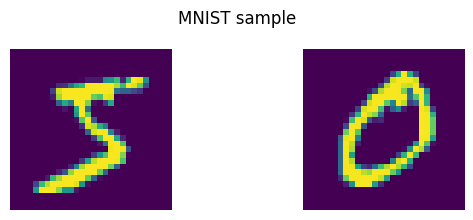

In [70]:
#自己的解答
plt.figure(figsize=(6,4))
plt.suptitle("MNIST sample") #整張 figure 的總標題 ; title 是「某一張子圖的標題」

plt.subplot(2,2,1)
plt.imshow(X_train[0])
plt.axis('off') #把x、y軸刻度關掉

plt.subplot(2,2,2)
plt.imshow(X_train[1])
plt.axis('off') #把x、y軸刻度關掉

plt.tight_layout()  #拉開邊界、幫標題留空間、幫軸標籤留空間、子圖不互撞
plt.show()

 dense1(flatten(X_train[:16]))
dense2(dense1(flatten(X_train[:16])))

在做:
 X

 ↓

Flatten

 ↓

Dense(128, relu)

 ↓

Dense(10, softmax)


---
dense1=K.layers.Dense(128,'relu')


1 個 Dense（無 hidden layer）
→ 線性模型

≥ 1 個 hidden Dense（有 activation）
→ 非線性模型


---

128可以改:

**改小：**

模型簡單、不容易 overfit、表達力弱

**改大：**

表達力強、容易 overfit、計算量大


---
dense2=K.layers.Dense(10,'softmax')

為什麼最後一層一定是 10 + softmax？

因為要的是：

「這張圖是 0~9 的機率分佈」

[0.01, 0.02, ..., 0.90, ...]


softmax 會：

保證加起來 = 1

可以當「信心值」


In [71]:
#一次性的 forward 試跑(下面def才是正式)
flatten=K.layers.Flatten()
dense1=K.layers.Dense(128,'relu')   #抽象特徵 ReLU = 非線性
dense2=K.layers.Dense(10,'softmax')  #分類決策
#flatten(X_train[:16])  #(16, H, W) → (16, H*W)
#將二維攤平成一維 (28,28) → (784)
dense1(flatten(X_train[:BATCH_SIZE]))
dense2(dense1(flatten(X_train[:BATCH_SIZE])))
# 第一個 Dense：學「中間特徵」
# 第二個 Dense：做「最終決策」


<tf.Tensor: shape=(16, 10), dtype=float32, numpy=
array([[0.11312915, 0.04296384, 0.11712051, 0.06614174, 0.20703399,
        0.08428245, 0.08182344, 0.06816477, 0.09603781, 0.12330238],
       [0.09196475, 0.0493946 , 0.07568713, 0.14746232, 0.16840762,
        0.11878037, 0.06572115, 0.07898756, 0.07848784, 0.12510663],
       [0.08556672, 0.05098388, 0.09616609, 0.1298485 , 0.11291298,
        0.11874426, 0.08449334, 0.12885493, 0.11222266, 0.08020664],
       [0.12716246, 0.05430937, 0.10046157, 0.06361857, 0.10259641,
        0.12064157, 0.06261634, 0.15520374, 0.08531585, 0.12807421],
       [0.08810654, 0.07219091, 0.07313222, 0.11023697, 0.14371924,
        0.11135557, 0.07144323, 0.07858238, 0.08817691, 0.16305603],
       [0.09838311, 0.06312728, 0.0948006 , 0.13018125, 0.07817411,
        0.10340033, 0.05482953, 0.13624562, 0.0974854 , 0.14337276],
       [0.08840331, 0.06851458, 0.05722465, 0.11076368, 0.20698936,
        0.06944245, 0.05440138, 0.08865695, 0.13653488, 0.11

In [72]:
from matplotlib.cbook import flatten
class MyDenseModel(K.Model):  #K.Model是來自 from tensorflow import keras as K
  def __init__(self):
    super().__init__()   #繼承父類別:K.Model
    self.flatten=K.layers.Flatten()
    self.dense1= K.layers.Dense(128,'relu')
    self.dense2= K.layers.Dense(10,'softmax')

  def call(self,x):
    y=self.flatten(x)
    y=self.dense1(y)
    y=self.dense2(y)
    return y

In [73]:
model=MyDenseModel()
model(X_train[:BATCH_SIZE])

<tf.Tensor: shape=(16, 10), dtype=float32, numpy=
array([[0.08701843, 0.04374328, 0.25388995, 0.05997939, 0.07930967,
        0.06015656, 0.07082696, 0.07392194, 0.09250806, 0.17864577],
       [0.07672294, 0.06678745, 0.14545885, 0.07441087, 0.06276062,
        0.125872  , 0.06189683, 0.06561165, 0.05779384, 0.26268485],
       [0.12320247, 0.06087398, 0.1210191 , 0.10166146, 0.07445366,
        0.09399888, 0.10290367, 0.08217949, 0.11830317, 0.12140404],
       [0.06648445, 0.05891267, 0.17012158, 0.09359851, 0.1320927 ,
        0.08286869, 0.08086228, 0.0932356 , 0.08281376, 0.13900965],
       [0.12717415, 0.06184261, 0.15492636, 0.12978517, 0.05045124,
        0.10816159, 0.083854  , 0.06843546, 0.05024358, 0.16512583],
       [0.07088823, 0.03897218, 0.23261566, 0.0926663 , 0.12727925,
        0.06169545, 0.0904341 , 0.05326244, 0.09542107, 0.13676518],
       [0.13384975, 0.07573391, 0.14097774, 0.10667317, 0.10886762,
        0.05200708, 0.06909879, 0.06044377, 0.0787531 , 0.17

In [74]:
model.summary() #試跑一次


Model: "my_dense_model_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_9 (Flatten)             │ (16, 784)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (16, 128)              │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (16, 10)               │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [75]:
784*128+128 # param算法

100480

In [78]:
optimizer=K.optimizers.Adam(LEARNING_RATE)
loss=K.losses.SparseCategoricalCrossentropy()
model.compile(optimizer,loss,metrics=['accuracy'])
# 訓練靠 loss
# 觀察靠 accuracy

model.fit(

    X_train,
    y_train,
    batch_size=16,
    epochs=3,
    validation_data=(X_val, y_val)
)

validation_data: 不拿來訓練，只拿來檢查，看有沒有 overfitting


In [79]:
model.fit(X_train,y_train,BATCH_SIZE,EPOCHS)

Epoch 1/3
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9840 - loss: 0.0511
Epoch 2/3
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9872 - loss: 0.0388
Epoch 3/3
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9907 - loss: 0.0311


# metrics=['accuracy']補充

看任務。

✔ 分類（最常見）
metrics=['accuracy']

✔ 不平衡資料
metrics=['precision', 'recall']

✔ 回歸
metrics=['mse', 'mae']

✔ 研究或作業

👉 通常都會加，因為要報告數字



---

 **accuracy 不會影響訓練嗎？（再次強調）**

❌ 不影響梯度

❌ 不影響權重更新

❌ 不影響收斂


✔ 只影響你看到的 log


把它接回你現在的學習狀態（很重要）

---



**你現在會注意到這一行：**

metrics=['accuracy']


代表你已經開始在想：

「這一行是不是必要？
它對模型做了什麼？」

這個層級，已經不是照抄 code 的人了。


---



**一句話總結**

loss 是給機器看的，
metrics 是給人看的。



```
# 1. 訓練
model.fit(X_train, y_train)

# 2. 預測
y_prob = model.predict(X_test)

# 3. 轉成類別
y_pred = np.argmax(y_prob, axis=1)

# 4. 評估
print((y_pred == y_test).mean())

```



In [83]:
y_prob = model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [84]:
acc = (y_pred == y_test).mean()
print("Test accuracy:", acc)


Test accuracy: 0.9755
